# Task 1.2: Correlation

**Student Name:** Haris Salii  
**Country:** Switzerland  
**Semester term:** HS26  


## Day 6 Data & Domain

### Use Case
*Focus: domain and application context*

> Für die kurzfristige Betriebsplanung einer Photovoltaikanlage im Raum Bern soll untersucht werden, ob sich der tägliche Verlauf der Globalstrahlung wiederholt und wann ein bestimmtes Muster aus Anstieg, Wolkeneinbruch und Erholung erneut auftritt. Die Tagesperiodik unterstützt die zeitliche Planung von Batteriebeladung und Netzeinspeisung; ähnliche starke Schwankungsmuster können auf Zeitfenster mit erhöhtem Bedarf an kurzfristiger Leistungsreserve hinweisen. Der Anwendungsfall ist für die Schweiz relevant, weil der Ausbau der Solarenergie eine verlässliche Einschätzung wetterabhängiger Einspeisung erfordert.



### Problem Statement
*Focus: technical vulnerability*

> Solarstrahlung besitzt einen wiederkehrenden Tag-Nacht-Verlauf, dessen Form und Amplitude durch Bewölkung täglich verändert werden. Eine Betrachtung einzelner Schwellenwerte kann ähnliche zeitliche Verläufe übersehen, während lange nächtliche Nullphasen eine Ähnlichkeitsanalyse dominieren können. Die technische Aufgabe besteht deshalb darin, die ungefähre Tagesperiodik von einem konkreten mehrstündigen Schwankungsmuster zu unterscheiden und gefundene Ähnlichkeit nicht automatisch als gleiche Wetterursache zu interpretieren.

### Experimental Objective
*Focus: investigation goal at the conceptual level.*

> Ziel ist es, in einem zusammenhängenden siebentägigen Signalfenster sowohl die wiederkehrende Tagesstruktur als auch die Position eines ausgewählten sechsstündigen Einstrahlungsmusters nachvollziehbar zu erkennen. Später soll beurteilt werden, wie zuverlässig diese Erkennung bei veränderter Signalstärke und realistischen Messstörungen bleibt.


### Data Definition, Source, and Visualization
*Focus: data characteristics, data source, and visual inspection.*

> Verwendet wird die Globalstrahlung `gre000z0` der MeteoSwiss-Station Bern/Zollikofen (`BER`) in W/m². Der Messwert entsteht aus direkter und diffuser Sonnenstrahlung und liegt als gleichmässig erfasster 10-Minuten-Mittelwert vor. Als einziges repräsentatives Signalfenster werden sieben vollständige Tage vom 19. Juli 2025, 00:00 Uhr, bis 25. Juli 2025, 23:50 Uhr, ausgewählt. Der astronomische Tag-Nacht-Zyklus erzeugt eine wiederkehrende Grundstruktur, während wechselnde Bewölkung innerhalb der Tagesabschnitte unterscheidbare Einbrüche und Erholungen verursacht. Die Daten stammen aus dem offiziellen MeteoSwiss-Datensatz „Automatic Weather Stations Measurement Values“ und sind wegen ihrer dokumentierten Herkunft und lückenlosen gleichmässigen Abtastung für die Untersuchung geeignet.

Die Grafik zeigt das vollständige ausgewählte Wochenfenster. Der orange markierte Abschnitt vom 21. Juli zwischen 09:00 und 15:00 Uhr ist das spätere Suchmuster für die Kreuzkorrelation und bleibt Teil desselben Signalfensters.

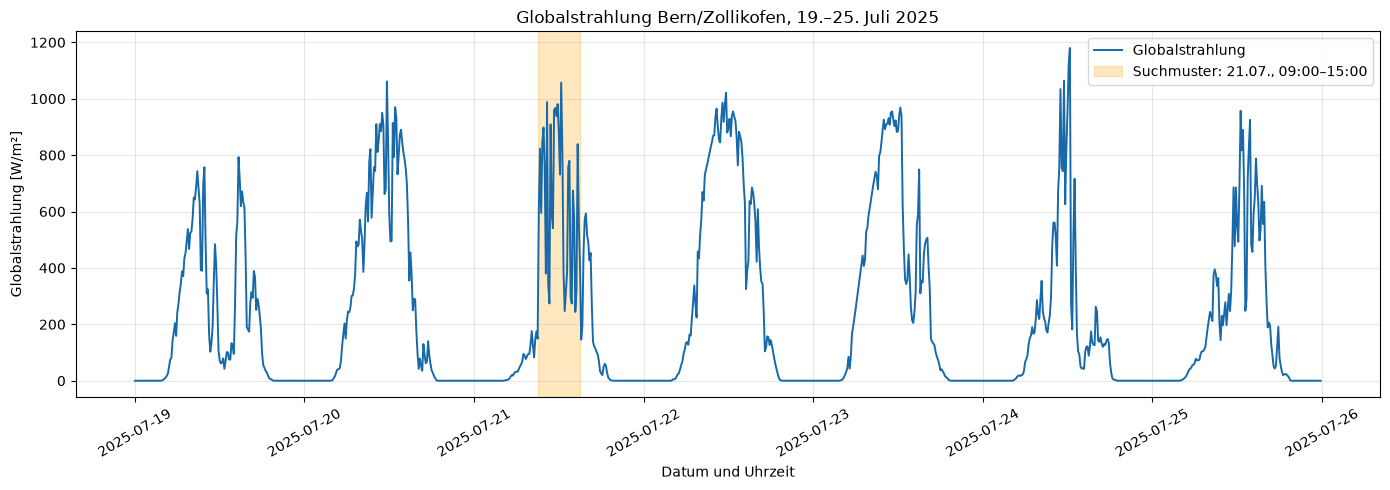

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv(
    "../data/solarstrahlung_bern_2025.csv",
    sep=";"
)
data["time"] = pd.to_datetime(
    data["reference_timestamp"],
    dayfirst=True
)

window_start = pd.Timestamp("2025-07-19 00:00")
window_end = pd.Timestamp("2025-07-26 00:00")
template_start = pd.Timestamp("2025-07-21 09:00")
template_end = pd.Timestamp("2025-07-21 15:00")

signal_window = data[
    (data["time"] >= window_start)
    & (data["time"] < window_end)
].copy()

plt.figure(figsize=(14, 5))
plt.plot(
    signal_window["time"],
    signal_window["gre000z0"],
    color="#1769aa",
    linewidth=1.4,
    label="Globalstrahlung"
)
plt.axvspan(
    template_start,
    template_end,
    color="orange",
    alpha=0.25,
    label="Suchmuster: 21.07., 09:00–15:00"
)
plt.title("Globalstrahlung Bern/Zollikofen, 19.–25. Juli 2025")
plt.xlabel("Datum und Uhrzeit")
plt.ylabel("Globalstrahlung [W/m²]")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Observations**:
> Im Wochenfenster ist an allen sieben Tagen ein Anstieg am Morgen und ein Rückgang am Abend sichtbar, getrennt durch nächtliche Abschnitte nahe 0 W/m². Höhe und Form der Tagesverläufe unterscheiden sich deutlich. Der markierte Abschnitt am 21. Juli enthält mehrere rasche Einbrüche und Erholungen innerhalb des allgemeinen Tagesanstiegs. Damit enthält dasselbe Fenster sowohl eine wiederkehrende globale Struktur als auch ein klar abgrenzbares lokales Muster.

### Begründung der Korrelationsanalyse

> Die Autokorrelation ist für die globale Fragestellung geeignet, weil sie das Signal mit zeitlich verschobenen Versionen seiner selbst vergleicht; eine wiederkehrende Tagesstruktur sollte daher bei Verschiebungen um ungefähr 24 Stunden erhöhte Ähnlichkeit zeigen. Die Kreuzkorrelation ist für die lokale Fragestellung geeignet, weil sie die vollständige Form des sechsstündigen Suchmusters entlang des Wochenfensters vergleicht und nicht nur einzelne Strahlungswerte prüft. Korrelationsspitzen zeigen statistische Formähnlichkeit, belegen aber weder identische Wetterbedingungen noch eine kausale Beziehung.

## Day 7 Methodological Design

### Theoretical Foundation and Method Choice
*Focus: principled justification aligned with the use case*

> Für die wiederkehrende globale Struktur verwende ich eine normalisierte Autokorrelation. Dabei wird das Wochenfenster mit zeitlich verschobenen Versionen von sich selbst verglichen; ein erhöhtes Korrelationsmaximum in der Nähe von 24 Stunden entspricht dem erwarteten Tag-Nacht-Zyklus. Für die lokale Mustersuche verwende ich eine normalisierte Kreuzkorrelation, bei der der Abschnitt vom 21. Juli zwischen 09:00 und 15:00 Uhr entlang des gesamten Wochenfensters verschoben wird. Autokorrelation beantwortet damit die Frage nach einer wiederkehrenden Periode, während Kreuzkorrelation die Position eines bestimmten sechsstündigen Verlaufs bestimmt.

### Parameter Definition and Mathematical Specification
*Focus: explicit parameter selection, derivation, and unit consistency*

Die Daten besitzen ein 10-Minuten-Raster; das siebentägige Fenster enthält damit 1'008 Messwerte. Für die Autokorrelation wird bei jedem Lag $k$ der Korrelationskoeffizient der beiden überlappenden, zentrierten Signalteile berechnet:

$$
r_{xx}(k)=\operatorname{corr}(x_{0:N-k},x_{k:N})
$$

Der Lag-Bereich von 0 bis 48 Stunden beziehungsweise 0 bis 288 Messschritten enthält den erwarteten Tagesabstand von 24 Stunden sowie eine zweite mögliche Wiederholung und lässt gleichzeitig noch genügend überlappende Werte übrig. Für die Kreuzkorrelation wird der Abschnitt vom 21. Juli, 09:00 bis 15:00 Uhr, als 36 Messwerte langes Suchmuster verwendet, weil er mehrere gut unterscheidbare Einbrüche und Erholungen enthält. Das Suchmuster und jedes gleich lange Fenster werden standardisiert und mit dem Pearson-Korrelationskoeffizienten verglichen; als Fundstelle gilt das Maximum, während Fenster mit nahezu keiner Streuung ausgeschlossen werden und 21. Juli 09:00 Uhr als Referenzstart dient.

### Experimental Design for Next Days
*Focus: structured parameter variation and theoretical prediction*

> In Day 8 wird zuerst die normalisierte Autokorrelation bis 48 Stunden berechnet und zusammen mit der erwarteten Referenzperiode von 24 Stunden dargestellt. Als erkannte Tagesperiode gilt das stärkste lokale Maximum im Bereich von 20 bis 28 Stunden. Danach wird das standardisierte sechsstündige Suchmuster über alle gültigen Positionen des Wochenfensters geschoben; der höchste Kreuzkorrelationswert liefert die erkannte Startzeit und wird mit der bekannten Startzeit verglichen. Zeitfenster, 10-Minuten-Abtastung, Lag-Bereich, Musterlänge und Normalisierung bleiben dabei unverändert.

### Methodological Limitations and Risk Factors
*Focus: assumptions, stability, and potential misinterpretation*

> Die Autokorrelation kann eine deutliche 24-Stunden-Struktur zeigen, obwohl diese teilweise durch die regelmässigen Nachtwerte nahe null und nicht durch ähnliche Bewölkung verursacht wird. Bei der Kreuzkorrelation ist die unveränderte Vorlage im Suchsignal enthalten, weshalb der höchste Wert in Day 8 zunächst eine technische Funktionskontrolle darstellt; die Robustheit wird erst in Day 9 mit Störungen geprüft. Durch die Standardisierung können zudem Verläufe mit ähnlicher Form, aber deutlich anderer Strahlungsstärke hohe Werte erreichen, während Fenster mit nahezu konstanter Nachtstrahlung wegen ihrer sehr kleinen Standardabweichung ausgeschlossen werden müssen.

## Day 8 Implementation

*Focus: structured, traceable execution*


### Vorbereitung

Die Messwerte und Zeitpunkte stammen aus dem in Day 6 ausgewählten Wochenfenster. Es werden zwei kurze Hilfsfunktionen verwendet: Die erste berechnet die Autokorrelation für verschiedene Verschiebungen, die zweite schiebt eine Vorlage durch das Signal und berechnet an jeder Position die Pearson-Korrelation.

In [2]:
import numpy as np

sampling_minutes = 10
samples_per_hour = 6

signal_values = signal_window["gre000z0"].to_numpy(dtype=float)
signal_times = signal_window["time"].reset_index(drop=True)

template_start = pd.Timestamp("2025-07-21 09:00")
template_hours = 6
reference_index = int(np.where(signal_times == template_start)[0][0])
template_length = template_hours * samples_per_hour
template_values = signal_values[
    reference_index:reference_index + template_length
]


def calculate_autocorrelation(values, max_lag):
    correlations = []
    for lag in range(max_lag + 1):
        if lag == 0:
            correlation = 1.0
        else:
            correlation = np.corrcoef(values[:-lag], values[lag:])[0, 1]
        correlations.append(correlation)
    return np.array(correlations)


def calculate_crosscorrelation(values, template):
    correlations = []
    number_of_positions = len(values) - len(template) + 1

    for start in range(number_of_positions):
        segment = values[start:start + len(template)]
        if np.std(segment) == 0:
            correlation = np.nan
        else:
            correlation = np.corrcoef(template, segment)[0, 1]
        correlations.append(correlation)

    return np.array(correlations)


print("Messwerte im Wochenfenster:", len(signal_values))
print("Messwerte in der Vorlage:", len(template_values))
print("Referenzstart:", template_start)

Messwerte im Wochenfenster: 1008
Messwerte in der Vorlage: 36
Referenzstart: 2025-07-21 09:00:00


### Autokorrelation: Tagesstruktur

Die Autokorrelation wird bis 48 Stunden berechnet. Als erkannte Tagesperiode gilt der höchste Korrelationswert im vorher festgelegten Bereich von 20 bis 28 Stunden.

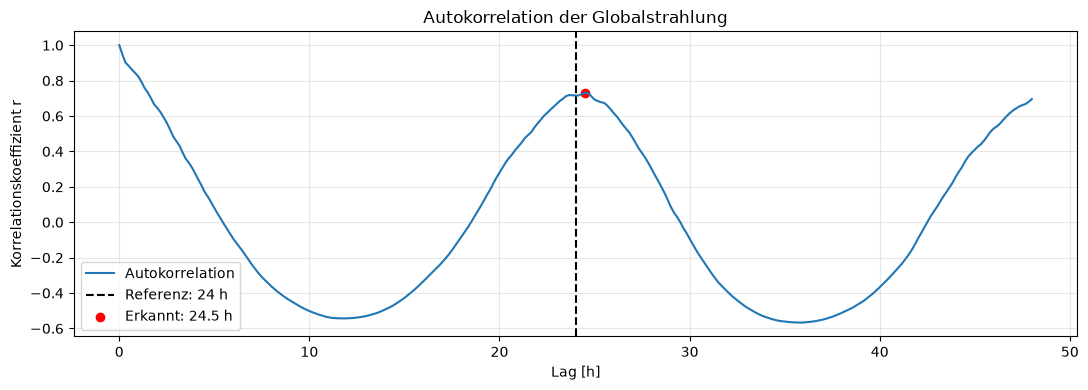

Erkannte Periode: 24.5 Stunden
Korrelationswert: 0.731


In [3]:
max_lag = 48 * samples_per_hour
acf = calculate_autocorrelation(signal_values, max_lag)
lag_hours = np.arange(len(acf)) / samples_per_hour

search_positions = np.where(
    (lag_hours >= 20) & (lag_hours <= 28)
)[0]
detected_lag = search_positions[np.nanargmax(acf[search_positions])]

detected_period = lag_hours[detected_lag]
detected_acf = acf[detected_lag]

plt.figure(figsize=(11, 4))
plt.plot(lag_hours, acf, label="Autokorrelation")
plt.axvline(24, color="black", linestyle="--", label="Referenz: 24 h")
plt.scatter(
    detected_period,
    detected_acf,
    color="red",
    label=f"Erkannt: {detected_period:.1f} h",
)
plt.xlabel("Lag [h]")
plt.ylabel("Korrelationskoeffizient r")
plt.title("Autokorrelation der Globalstrahlung")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Erkannte Periode: {detected_period:.1f} Stunden")
print(f"Korrelationswert: {detected_acf:.3f}")

### Kreuzkorrelation: Position des Suchmusters

Die Sechs-Stunden-Vorlage wird an jede mögliche Position des Wochenfensters geschoben. Der höchste Korrelationswert bestimmt den erkannten Start.

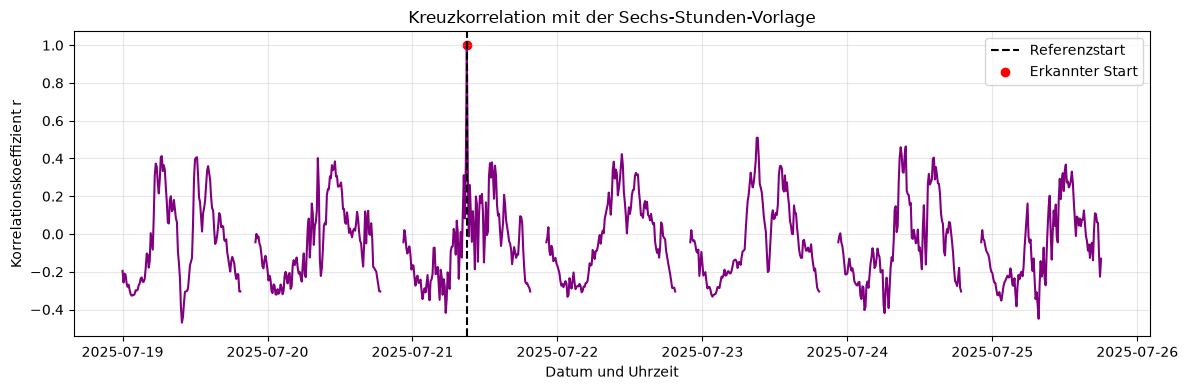

Referenzstart: 2025-07-21 09:00:00
Erkannter Start: 2025-07-21 09:00:00
Positionsfehler: 0 Minuten


In [4]:
crosscorrelation = calculate_crosscorrelation(
    signal_values,
    template_values,
)
candidate_times = signal_times.iloc[:len(crosscorrelation)]

detected_index = int(np.nanargmax(crosscorrelation))
detected_time = candidate_times.iloc[detected_index]
position_error = abs(detected_index - reference_index) * sampling_minutes

plt.figure(figsize=(12, 4))
plt.plot(candidate_times, crosscorrelation, color="purple")
plt.axvline(
    template_start,
    color="black",
    linestyle="--",
    label="Referenzstart",
)
plt.scatter(
    detected_time,
    crosscorrelation[detected_index],
    color="red",
    label="Erkannter Start",
)
plt.xlabel("Datum und Uhrzeit")
plt.ylabel("Korrelationskoeffizient r")
plt.title("Kreuzkorrelation mit der Sechs-Stunden-Vorlage")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Referenzstart:", template_start)
print("Erkannter Start:", detected_time)
print("Positionsfehler:", position_error, "Minuten")

### Ergebnis von Day 8 

Das Maximum der Autokorrelation liegt bei 24,5 Stunden. Die Kreuzkorrelation erkennt den bekannten Start am 21. Juli 2025 um 09:00 Uhr ohne Zeitfehler. Dieser perfekte Treffer ist zunächst nur eine Funktionskontrolle, weil die unveränderte Vorlage aus demselben Signal stammt.

## Day 9 – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

<span style="background-color: #eeeeee;">*Systematically evaluate the predefined experiment design in relation to the defined use case. The evaluation must be traceable, structured, and based on consistent criteria. All reported metrics or extracted quantities must include appropriate physical units or clearly indicate normalization to ensure consistent and meaningful comparison. The same predefined evaluation approach must be applied consistently across all experiments and parameter configurations to maintain traceability and comparability. No new simulations, theoretical derivations, or interpretative discussion should be introduced.*</span>

### Evaluation Approach Definition

<span style="background-color: #eeeeee;">*Guidelines: Define 1–2 quantitative evaluation approaches, which may consist of numerical metrics and/or quantitatively interpretable visualizations. Justify why the selected approach is appropriate for your signal or image characteristics and application objective, and clearly specify what aspect of performance it captures (e.g., fidelity, detection accuracy, reconstruction quality, robustness, distortion). Visualizations must include labeled axes with units and enable measurable comparison across configurations. 2-3 sentences.*</span>

You may use the following structures as guidance, depending on whether your evaluation approach is metric-based or visualization-based.

#### Template – Metric-Based Evaluation

> The selected metric is __________, which quantifies ____________ in relation to [the defined use case].
It is specifically chosen because the problem statement requires accurate assessment of ____________, and this metric directly reflects changes in ____________.
The validity of this metric depends on ____________, which must hold for the evaluation to be meaningful in this application.

Example – Root Mean Squared Error (RMSE):

> The selected metric is RMSE, which quantifies the deviation between the reconstructed signal and the high-resolution reference. It is specifically chosen because [the use case] requires accurate amplitude reconstruction over time, and RMSE directly reflects reconstruction fidelity. The metric is meaningful here because a validated reference signal is available and serves as ground truth.

#### Template – Visualization-Based Evaluation

> The evaluation uses a __________ visualization, representing ____________ with clearly labeled axes and units.
The evaluated quantity is ____________, which is directly relevant to [the defined use case] because the problem requires reliable assessment of ____________.
This approach is appropriate under ____________, ensuring that the extracted feature meaningfully reflects performance in this application context.

Example – Frequency Spectrum Comparison:

> The evaluation uses a frequency spectrum visualization to assess whether dominant periodic components are preserved. The evaluated quantity is the measurable peak frequency and its amplitude, which are directly relevant because the use case requires reliable detection of periodic behavior. This approach is appropriate since frequency preservation is more critical than pointwise amplitude accuracy in this application.

### Evaluation Comparison Execution

<span style="background-color: #eeeeee;">*Guidelines: Apply the defined evaluation approach consistently across all predefined experiments or configurations. Systematically vary 2–4 previously defined key parameters and quantify their influence on performance relative to a clearly specified baseline configuration. Results must be reported in a structured format (e.g., tables or measurable graphics) to ensure traceability. 2-4 sentences.*</span>


#### Template – Parameter Evaluation (Metric-Based)

>The influence of key parameters __________ was evaluated using the previously defined metric __________.
These parameters are essential for [the defined use case] because they directly affect ____________, which is critical for ____________.
Changes in __________ [metric] across parameter settings quantify how sensitive the experiment design is to ____________.
Relative performance change was computed with respect to the baseline configuration ____________.

#### Template – Parameter Evaluation (Visualization-Based)

>The influence of key parameters __________ was evaluated using the previously defined visualization-based measure __________.
These parameters are essential for the defined use case because they influence ____________, which determines ____________ in [the application context].
Differences in the extracted quantity __________ across parameter settings quantify the impact of ____________ on performance.
Relative performance change was computed with respect to the baseline configuration ____________.

In [5]:
## Placeholder for code-based analysis, quantitative result reporting, and structured comparison using tables and/or graphics.

Example universal comparison table:

| Experiment / Configuration        | Metric / Quantity 1 | Metric / Quantity 2 (optional) | Relative Change to Baseline (%) |
|:----------------------------------|:--------------------|:--------------------------------|:--------------------------------|
| Baseline: ____________            |                     |                                  | 0%                               |
| Configuration 1: ____________     |                     |                                  |                                  |
| Configuration 2: ____________     |                     |                                  |                                  |
| Configuration 3: ____________     |                     |                                  |                                  |


Example for Sampling Rate Variation:


| Experiment / Configuration | RMSE | Relative Change to Baseline (%) |
|:----------------------------|:-----|:--------------------------------|
| Baseline: Fs = 100 Hz      | 0.12 | 0%                               |
| Fs = 50 Hz                 | 0.18 | +50%                             |
| Fs = 25 Hz                 | 0.45 | +275%                            |

## Day 10 – Analysis & Communication

*Focus: Analytical Interpretation and Domain-Specific Discussion*

<span style="background-color: #eeeeee;">*Guidelines: Based on the quantitative evaluation from the Evaluation day, critically analyze your findings in direct relation to your defined use case and selected signal or image. Structure your analysis into (1) observations, (2) interpretation, and (3) discussion. Observations must reference concrete quantitative results; interpretations must explain domain-specific implications; the discussion must critically assess the practical applicability, limitations, and risks of your implementation and evaluation approach. All arguments must explicitly connect to the original problem statement and use case. No new simulations or derivations may be introduced.*</span>

### Observations (3-5 sentences)
Focus: Describe measurable results only — no explanation.

> The quantitative evaluation shows that ____________ changes from ____________ to ____________ across configurations ____________.
The defined metric / extracted quantity indicates that ____________.
Performance differences are most pronounced when ____________.

### Interpretation (3-5 sentences)
Focus: Explain what the results mean for the application.

>In the context of ____________ [use case], these results imply that ____________.
The observed variation in ____________ affects ____________ because ____________.
This suggests that ____________ is particularly critical for achieving the objective defined in the problem statement.


### Discussion and Critical Reflection (4–6 sentences)
*Focus: Relate the quantitative findings to the requirements of the defined use case and assess practical adequacy.*

> For the defined use case, the configurations ____________ performed well because they achieved ____________, which aligns with the requirement of ____________.
In contrast, configurations ____________ showed reduced performance, leading to ____________ and limiting their suitability for this application.
The achieved performance level can be considered sufficient / insufficient for the use case because ____________.
The implementation and evaluation approach assumes ____________, which may be constrained under real-world conditions such as ____________.
To improve robustness or applicability, future work should address ____________ or refine ____________.

## Day 15 

### Final Reflections on MC
>Overall, the most successful aspect of MC1 was ____________, particularly in relation to ____________ within the defined use case. The implementation of ____________ worked well because ____________, leading to ____________.
If repeating this work, I would reconsider ____________ or refine ____________, as this could improve ____________ and reduce ____________. Certain challenges emerged during ____________, highlighting the importance of ____________ in practical signal/image analysis.
I was particularly impressed by ____________, especially how ____________ influenced ____________ in the context of the application.
Through this project, I learned that ____________, and I developed a clearer understanding of ____________, especially regarding the connection between theoretical principles and real-world constraints.

### Revisions
<span style="background-color: #fff3b0;"><strong>Template for Revisions:</strong> [your changes... ]</span>

### Sources and Tools

Data source: MeteoSwiss, “Automatic Weather Stations Measurement Values”, station Bern/Zollikofen (`BER`), parameter `gre000z0`.

https://opendatadocs.meteoswiss.ch/de/a-data-groundbased/a1-automatic-weather-stations

OpenAI ChatGPT/Codex was used for language correction, methodological feedback and support with coding.